After assigning labels:  [1, 1, 1, 1, 2, 1, 2, 2]
Updated tree centroids:  [(0.148, 0.712), (0.24666666666666667, 0.20000000000000004)]
New labels:  [1, 1, 1, 1, 2, 1, 2, 2]
Old labels:  [0, 0, 0, 0, 0, 0, 0, 0]
After assigning labels:  [1, 1, 1, 1, 2, 2, 2, 2]
Updated tree centroids:  [(0.1225, 0.765), (0.2475, 0.275)]
New labels:  [1, 1, 1, 1, 2, 2, 2, 2]
Old labels:  [1, 1, 1, 1, 2, 1, 2, 2]
After assigning labels:  [1, 1, 1, 1, 2, 2, 2, 2]
Updated tree centroids:  [(0.1225, 0.765), (0.2475, 0.275)]
New labels:  [1, 1, 1, 1, 2, 2, 2, 2]
Old labels:  [1, 1, 1, 1, 2, 2, 2, 2]


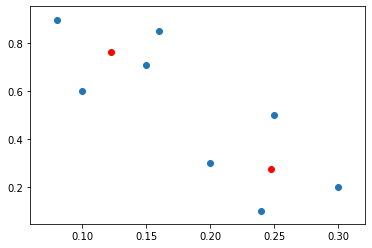

In [2]:
import math
import matplotlib.pyplot as plt

def manhattan_distance(x1,y1,x2,y2):
    return math.fabs(x1-x2)+math.fabs(y1-y2)

def assign_label(points,centroid,label):
    x1_c=centroid[0][0]
    y1_c=centroid[0][1]
    x2_c=centroid[1][0]
    y2_c=centroid[1][1]
    
    idx=0
    for p in points:
        x=p[0]
        y=p[1]
        
        dist1=manhattan_distance(x,y,x1_c,y1_c)
        dist2=manhattan_distance(x,y,x2_c,y2_c)
        
        if dist1<=dist2:
            label[idx]=1
        else:
            label[idx]=2
        idx+=1
        
    return

def get_centroid(datapoints,label):
    len1=0
    len2=0
    
    sum_1_x=0
    sum_1_y=0
    
    sum_2_x=0
    sum_2_y=0
    
    idx=0
    for points in datapoints:
        x=points[0]
        y=points[1]
        
        if label[idx]==1:
            len1+=1
            sum_1_x+=x
            sum_1_y+=y
        else:
            len2+=1
            sum_2_x+=x
            sum_2_y+=y
        idx+=1
        
    new_x_1=sum_1_x/len1
    new_y_1=sum_1_y/len1
    
    new_x_2=sum_2_x/len2
    new_y_2=sum_2_y/len2
    
    new_c1=(new_x_1,new_y_1)
    new_c2=(new_x_2,new_y_2)
    
    return (new_c1,new_c2)

def kmeans(datapoints,centroid,label,old_label):
    while label!=old_label:
        
        old_label=label.copy()
        assign_label(datapoints,centroid,label)
        print("After assigning labels: ",label)
        
        new_centroid=get_centroid(datapoints,label)
        
        centroid[0]=new_centroid[0]
        centroid[1]=new_centroid[1]
        
        print("Updated tree centroids: ", centroid)
        
        print("New labels: ",label)
        print("Old labels: ",old_label)
        
    return centroid

datapoints=[(0.1,0.6),
  (0.15,0.71),
  (0.08,0.9),
  (0.16, 0.85),
  (0.2,0.3),
  (0.25,0.5),
  (0.24,0.1),
  (0.3,0.2)]

centroid=[(0.1,0.6),
  (0.3,0.2)]

label=[0]*8
old_label=[-1]*8

new_centroid=kmeans(datapoints,centroid,label,old_label)

x=[d[0] for d in datapoints]
y=[d[1] for d in datapoints]

xc=[c[0] for c in new_centroid]
yc=[c[1] for c in new_centroid]

plt.scatter(x,y)
plt.scatter(xc,yc,color="red")
plt.show()
